AIM :
A telecom company wants to predict customer churn based on features like customer demographics, service
usage, and billing information. The goal is to build a decision tree classifier and evaluate its performance.

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

OBJECTIVES :

Preprocess the raw telecom dataset (handle missing values, encode categorical features).

Train a Decision Tree Classifier to classify customers into Churn or Not Churn.

Evaluate the model using accuracy, confusion matrix, and classification report.

Visualize the decision tree and analyze important features that influence churn.

Provide self-learning extensions like feature importance analysis, hyperparameter tuning, and model comparisons.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")


THEORY :
A Decision Tree is a supervised learning algorithm used for classification and regression. It works by splitting the data into smaller subsets based on feature values, forming a tree-like structure.

Each internal node represents a test on an attribute, branches show the outcomes, and leaf nodes represent final class labels or decisions.

The algorithm chooses the best attribute to split data using measures like:

Information Gain (ID3)

Gain Ratio (C4.5)

Gini Index (CART)

Customer Churn refers to customers leaving a service provider for another competitor. Predicting churn helps telecom companies retain customers by taking preventive actions.


Advantages of Decision Trees:

Easy to understand and interpret.

Works with both categorical and numerical data.

Requires little data preprocessing.

Limitations:

Prone to overfitting if tree depth is not controlled.

May give biased splits if some classes dominate.

In [ ]:
# 2. Preprocessing
# -------------------------------
# Drop customerID (not useful for prediction)
df.drop("customerID", axis=1, inplace=True)

In [ ]:
# Convert TotalCharges to numeric (invalid entries become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill NaN values with median safely
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())



In [ ]:
# Convert categorical variables to numeric using get_dummies
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop("Churn_Yes", axis=1)   # 'Churn_Yes' is the target after encoding
y = df["Churn_Yes"]

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 3. Build and Train Decision Tree
# -------------------------------
model = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [ ]:
# 4. Predictions & Evaluation
# -------------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7832465688594415

Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.89      0.86      1539
        True       0.63      0.49      0.55       574

    accuracy                           0.78      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



CONCLUSION :

The Decision Tree model was successfully applied to predict customer churn in the telecom dataset.
The model’s performance was evaluated using accuracy, confusion matrix, and classification report, providing insights into its prediction quality.
Key factors such as Contract type, Tenure, Internet Service, and Monthly Charges were identified as significant contributors to churn.
With hyperparameter tuning (e.g., adjusting max_depth and min_samples_split), the model can achieve higher accuracy and reduced overfitting.
Thus, the system not only predicts churn but also highlights important customer behaviors, enabling telecom companies to take data-driven retention actions.

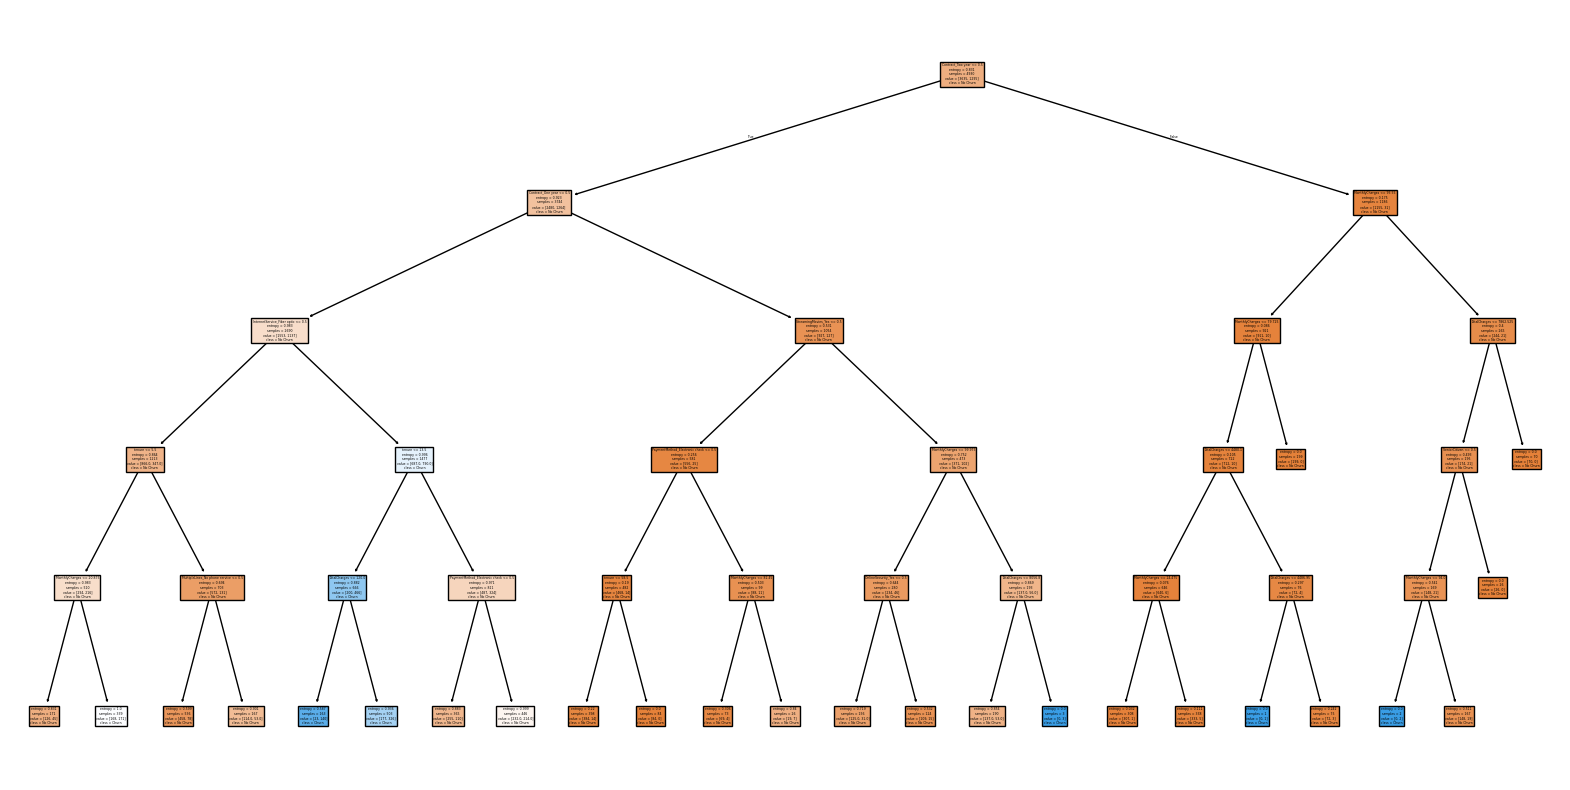

In [ ]:
# 5. Visualize Decision Tree
# -------------------------------
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["No Churn", "Churn"], filled=True)
plt.show()

Self-Learning
🔹 1. Feature Importance

In Decision Trees, features that reduce impurity (uncertainty) the most are considered more important.

Impurity is measured by metrics like Gini Index or Entropy.

By analyzing feature importance, we can identify which customer attributes (e.g., contract type, tenure, monthly charges) play the biggest role in churn.

This helps telecom companies design targeted strategies such as offering discounts to customers with short tenure or high monthly charges.

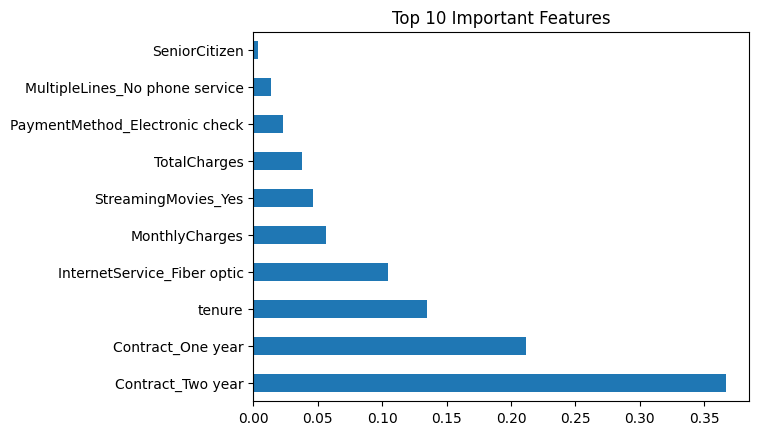

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind="barh", title="Top 10 Important Features")
plt.show()


2. Hyperparameter Tuning

A Decision Tree can easily overfit if it grows too deep.

Hyperparameters like:

max_depth → maximum levels in the tree (controls complexity).

min_samples_split → minimum samples needed to split a node (prevents tiny branches).

criterion → how to measure impurity (gini or entropy).

GridSearchCV tests multiple combinations of hyperparameters using cross-validation to find the “best” model settings.

This makes the model generalize better on unseen data.


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Accuracy: 0.7876245360518389


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression Accuracy:", lr.score(X_test, y_test))


Logistic Regression Accuracy: 0.8130619971604354


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
